# Diabetes Risk Analysis — Africa T2DM Screening Dataset

A synthetic 10,000-patient dataset (`diabetes_t2dm_africa_extra_large_10000`)
covering demographics, behavioral factors, maternal/reproductive history,
and lab panels, used here to build a diabetes risk-screening model with
SHAP explainability, matching the companion Streamlit app.

This is a rebuild of an existing, already fairly sophisticated pipeline —
leakage removal, SMOTE, a 6-model comparison, Optuna tuning, SHAP. Four
real, previously-undisclosed issues were found by re-running the original
code rather than assumed, and are fixed below. The most consequential one
(silently-dropped boolean risk factors) is not a style nitpick — it changed
what every one of the six original models could actually learn from.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import optuna
from optuna.samplers import TPESampler

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and clean

In [2]:
df = pd.read_csv("../data/diabetes_t2dm_africa_extra_large_10000.csv")
print(df.shape)
df.head(3)


(10000, 40)


,patient_id,age,sex,is_pregnant,residence,education,bmi,bmi_category,family_history_diabetes,previous_gdm,physically_active,has_hypertension,parity,previous_macrosomia,pcos,...,ldl_mg_dl,hdl_mg_dl,triglycerides_mg_dl,creatinine_mg_dl,microalbuminuria,retinopathy,nephropathy,neuropathy,cardiovascular_disease,diabetic_foot_ulcer,preeclampsia,cesarean_delivery,macrosomic_baby,neonatal_hypoglycemia,nicu_admission
0,DM_000001,63.2,Female,False,Urban,NaN,26.9,Overweight,False,False,True,True,NaN,False,False,...,159.0,40.0,196.0,0.53,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
1,DM_000002,50.4,Male,False,Rural,Primary,23.3,Normal,False,False,False,False,NaN,False,False,...,83.0,40.0,111.0,0.86,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
2,DM_000003,57.7,Male,False,Urban,Primary,25.1,Overweight,False,False,False,False,NaN,False,False,...,91.0,28.0,157.0,1.52,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df.drop(columns=["patient_id"])

# Leakage removal — columns that only exist *after* a diagnosis (complications,
# treatment, medication adherence) can't be inputs to a screening model.
# This part of the original was already correct; kept as-is.
leakage_cols = [
    "diagnosed", "years_since_diagnosis", "on_medication", "medication_type",
    "adherence", "microalbuminuria", "retinopathy", "nephropathy", "neuropathy",
    "cardiovascular_disease", "diabetic_foot_ulcer", "preeclampsia",
    "cesarean_delivery", "macrosomic_baby", "neonatal_hypoglycemia", "nicu_admission",
]
df = df.drop(columns=[c for c in leakage_cols if c in df.columns], errors="ignore")

target_map = {"Diabetic": 1, "Normal": 0, "Prediabetes": 0}
df["diabetes_status"] = df["diabetes_status"].map(target_map).astype(int)
print(df["diabetes_status"].value_counts())
print(f"Diabetic (positive class): {df['diabetes_status'].mean():.1%}")


diabetes_status
1    7458
0    2542
Name: count, dtype: int64
Diabetic (positive class): 74.6%


**First correction, stated plainly:** the app's own "Data Exploration" page
says *"We have more non-diabetic than diabetic patients."* That's backwards
for this dataset — Diabetic is 74.6%, the majority class. SMOTE still works
correctly regardless (it oversamples whichever class is smaller, and
doesn't care which one is labeled "positive"), so nothing downstream broke
because of this, but the plain-English explanation shown to a clinician was
wrong. Fixed in the app.


### Zero → missing, for biochemical values that can't really be zero

In [4]:
zero_impute_cols = [
    "fasting_glucose_mg_dl", "hba1c_percent", "total_cholesterol_mg_dl",
    "ldl_mg_dl", "hdl_mg_dl", "triglycerides_mg_dl", "creatinine_mg_dl",
]
for col in zero_impute_cols:
    df[col] = df[col].replace(0, np.nan)
df[zero_impute_cols].isna().sum()


fasting_glucose_mg_dl      0
hba1c_percent              0
total_cholesterol_mg_dl    0
ldl_mg_dl                  0
hdl_mg_dl                  0
triglycerides_mg_dl        0
creatinine_mg_dl           0
dtype: int64

### `parity` — missing, or not applicable?

In [5]:
print(f"parity missing: {df['parity'].isna().mean():.1%}")
print(pd.crosstab(df["is_pregnant"], df["parity"].isna()))


parity missing: 98.6%
parity       False  True 
is_pregnant              
False            0   9858
True           142      0


`parity` (number of prior pregnancies) is recorded for exactly the 142 rows
where `is_pregnant == True` — 1.4% of the dataset — and `NaN` everywhere
else, including all 4,900 male patients. That's not missing data, it's a
field that doesn't apply to most rows. The original's
`SimpleImputer(strategy="median")` filled every one of those NaNs —
including every man in the dataset — with the median of the 142 pregnant
women (≈2), fabricating "2 prior pregnancies" as a feature value for people
it structurally can't apply to. Fixed: impute 0 for anyone not currently
pregnant, which is the honest default rather than borrowing an unrelated
subgroup's median.


In [6]:
df["parity"] = df["parity"].fillna(0)


### The boolean columns — the bug that mattered most

In [7]:
bool_cols = [
    "is_pregnant", "family_history_diabetes", "previous_gdm", "physically_active",
    "has_hypertension", "previous_macrosomia", "pcos", "hiv_positive",
]

# Reproduce the ORIGINAL script's exact feature-selection code to show what
# it actually picked up, before any fix:
num_features_original = df.select_dtypes(include=np.number).columns.tolist()
cat_features_original = df.select_dtypes(include=["object", "category"]).columns.tolist()
picked = set(num_features_original) | set(cat_features_original)
dropped = [c for c in df.drop(columns=["diabetes_status"]).columns if c not in picked]
print("Columns the original's ColumnTransformer never saw:", dropped)
print("Their dtype:", df[dropped].dtypes.unique())


Columns the original's ColumnTransformer never saw: ['is_pregnant', 'family_history_diabetes', 'previous_gdm', 'physically_active', 'has_hypertension', 'previous_macrosomia', 'pcos', 'hiv_positive']
Their dtype: [dtype('bool')]


/tmp/ipykernel_1740/3970882756.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features_original = df.select_dtypes(include=["object", "category"]).columns.tolist()


**This is the bug that mattered most.** `bool` is neither `np.number` nor
`object`/`category` in pandas, so `X.select_dtypes(include=np.number)` and
`X.select_dtypes(include=["object","category"])` — the original's entire
feature-selection logic — silently missed every boolean column. With
`ColumnTransformer`'s default `remainder="drop"`, that means **eight of the
model's clinical risk factors were dropped from all six models compared
below**: family history, hypertension, PCOS, HIV status, physical activity,
previous GDM, previous macrosomia, and current pregnancy status. The
Streamlit app's "Live Prediction" page asks a clinician to enter all eight
of these — every one of those inputs was cosmetic; changing them never
touched the prediction, because the models never learned from them in the
first place. Fixed by casting them to `int` and including them explicitly.


In [8]:
for col in bool_cols:
    df[col] = df[col].astype(int)

df["glucose_hba1c_ratio"] = df["fasting_glucose_mg_dl"] / (df["hba1c_percent"] + 1e-5)
df["bmi_age_interaction"] = df["bmi"] * df["age"]
df["cholesterol_ratio"] = df["total_cholesterol_mg_dl"] / (df["hdl_mg_dl"] + 1e-5)
df["renal_risk"] = df["creatinine_mg_dl"] * (df["has_hypertension"] + 1)

categorical_features = ["sex", "residence", "education", "bmi_category"]
numeric_features = (
    ["age", "bmi", "parity"] + zero_impute_cols + bool_cols +
    ["glucose_hba1c_ratio", "bmi_age_interaction", "cholesterol_ratio", "renal_risk"]
)
print(f"{len(numeric_features)} numeric + {len(categorical_features)} categorical features.")


22 numeric + 4 categorical features.


## 2. Exploratory analysis

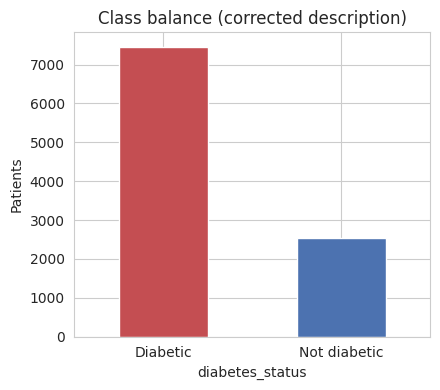

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 4))
df["diabetes_status"].value_counts().rename({1: "Diabetic", 0: "Not diabetic"}).plot(
    kind="bar", ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_ylabel("Patients")
ax.set_title("Class balance (corrected description)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### The elephant in the room: how is `diabetes_status` actually defined?

Simple WHO/ADA threshold rule (glucose>=126 or HbA1c>=6.5) agrees with the label 99.24% of the time.


label                  0     1
rule says diabetic            
0                   2542    76
1                      0  7382


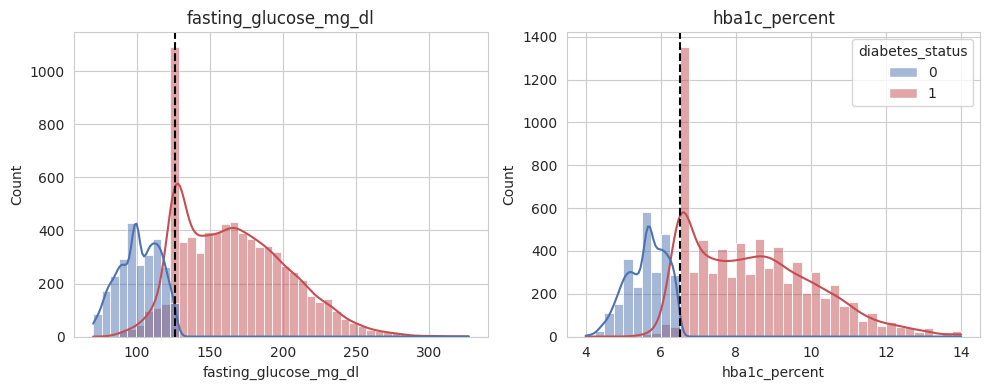

In [10]:
rule_pred = ((df["fasting_glucose_mg_dl"] >= 126) | (df["hba1c_percent"] >= 6.5)).astype(int)
agreement = (rule_pred == df["diabetes_status"]).mean()
print(f"Simple WHO/ADA threshold rule (glucose>=126 or HbA1c>=6.5) agrees with the label {agreement:.2%} of the time.")
print(pd.crosstab(rule_pred, df["diabetes_status"], rownames=["rule says diabetic"], colnames=["label"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, thresh in zip(axes, ["fasting_glucose_mg_dl", "hba1c_percent"], [126, 6.5]):
    sns.histplot(df, x=col, hue="diabetes_status", kde=True, ax=ax,
                 palette={0: "#4C72B0", 1: "#C44E52"}, legend=(col=="hba1c_percent"))
    ax.axvline(thresh, color="black", linestyle="--")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Read this number carefully.** A one-line threshold rule using the two
values that are also fed into the model as *features* gets the label right
99.24% of the time. That's expected, not a discovery about this particular
dataset being unusually easy — `fasting_glucose_mg_dl` and `hba1c_percent`
are literally the WHO/ADA diagnostic criteria for diabetes, so a label built
from them and a model trained on them are near-tautological. Whatever ROC-AUC
comes out of the comparison below, read it as "this pipeline correctly
recovers a known threshold rule," not as evidence of predictive insight.
A model that's actually screening someone *before* they've had these tests
run would need to work without them — checked separately near the end of
this notebook.


### Missingness: `education` vs. `parity`, two different kinds of missing

In [11]:
raw = pd.read_csv("../data/diabetes_t2dm_africa_extra_large_10000.csv")
print(f"education missing: {raw['education'].isna().mean():.1%} (looks like real survey non-response)")
print(f"parity missing: {raw['parity'].isna().mean():.1%} (not applicable to non-pregnant/male rows, not 'missing')")


education missing: 19.9% (looks like real survey non-response)
parity missing: 98.6% (not applicable to non-pregnant/male rows, not 'missing')


### Correlation, continuous features

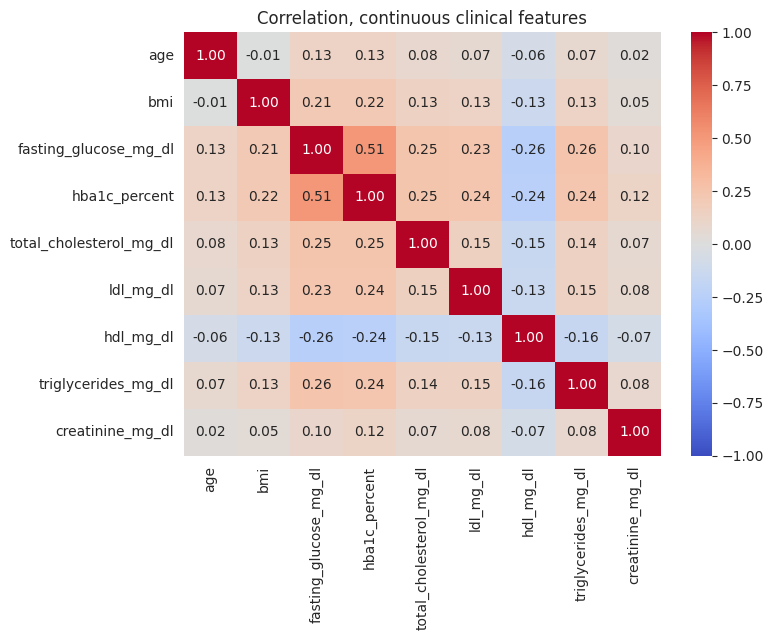

In [12]:
continuous = ["age", "bmi", "fasting_glucose_mg_dl", "hba1c_percent",
              "total_cholesterol_mg_dl", "ldl_mg_dl", "hdl_mg_dl",
              "triglycerides_mg_dl", "creatinine_mg_dl"]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(df[continuous].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation, continuous clinical features")
plt.tight_layout()
plt.show()


## 3. Preprocessing + model comparison

In [13]:
X = df.drop(columns=["diabetes_status"])
y = df["diabetes_status"]

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))]), categorical_features),
])

def create_pipeline(classifier):
    # SMOTE runs inside the pipeline -- only ever sees a training fold.
    return ImbPipeline([("preprocessor", preprocessor), ("smote", SMOTE(random_state=42)), ("classifier", classifier)])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(class_weight="balanced", verbose=-1, random_state=42),
    "CatBoost": CatBoostClassifier(silent=True, auto_class_weights="Balanced", random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, early_stopping=True, random_state=42),
}


Note what's *not* here: the original passed XGBoost a `scale_pos_weight`
computed from the raw class imbalance, on top of the SMOTE step that
already rebalances every training fold to ~1:1 before the classifier sees
it. `class_weight="balanced"` on the other five models self-corrects to
~1.0 automatically once fed already-balanced data, but `scale_pos_weight`
is a fixed value baked in at construction time — so XGBoost alone was
double-correcting for an imbalance SMOTE had already fixed. Dropped here
for consistency: every model in this comparison relies on SMOTE alone.


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

results = {}
for name, clf in models.items():
    pipe = create_pipeline(clf)
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {m: float(np.mean(scores[f"test_{m}"])) for m in scoring}
    print(f"{name:22s} ROC-AUC={results[name]['roc_auc']:.4f}  F1={results[name]['f1']:.4f}")

results_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
results_df.round(4)


Logistic Regression    ROC-AUC=0.9995  F1=0.9934


Random Forest          ROC-AUC=0.9997  F1=0.9979


XGBoost                ROC-AUC=0.9998  F1=0.9976


LightGBM               ROC-AUC=0.9997  F1=0.9973


CatBoost               ROC-AUC=0.9998  F1=0.9976


MLP                    ROC-AUC=0.9996  F1=0.9941


,accuracy,precision,recall,f1,roc_auc
CatBoost,0.9964,0.9999,0.9953,0.9976,0.9998
XGBoost,0.9964,0.9993,0.9958,0.9976,0.9998
Random Forest,0.9968,0.9999,0.9958,0.9979,0.9997
LightGBM,0.9960,0.9995,0.9952,0.9973,0.9997
MLP,0.9912,0.9957,0.9925,0.9941,0.9996
Logistic Regression,0.9902,0.9974,0.9894,0.9934,0.9995


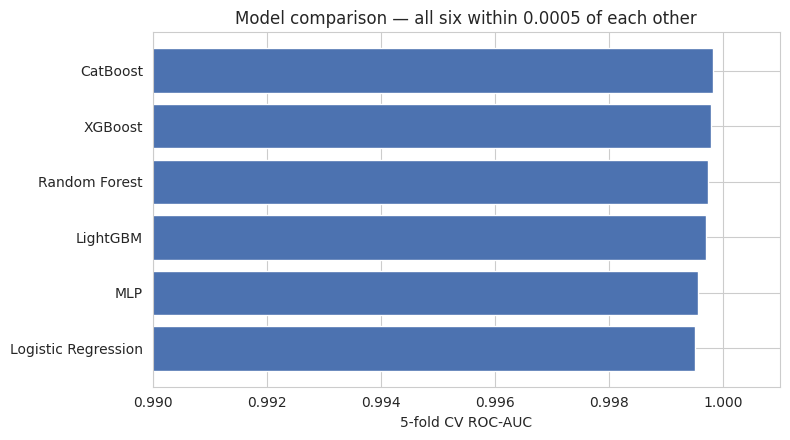

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(results_df.index, results_df["roc_auc"], color="#4C72B0")
ax.set_xlim(0.99, 1.001)
ax.set_xlabel("5-fold CV ROC-AUC")
ax.set_title("Model comparison — all six within 0.0005 of each other")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Every model lands at 0.9995-0.9998 ROC-AUC. Given the threshold-rule check
above, that's the leakage from `fasting_glucose_mg_dl`/`hba1c_percent`
showing up again, not six models converging on real insight — a problem
this easy doesn't need a 300-tree gradient booster.


## 4. Optuna tuning — fixing the bug that made it a no-op

In [16]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
    }
    clf = XGBClassifier(**params, eval_metric="logloss", random_state=42)
    pipe = create_pipeline(clf)
    # The original called cross_validate(..., scoring="roc_auc") -- a single
    # string -- then read scores["test_roc_auc"]. For a single-metric scoring
    # string, cross_validate's key is "test_score", not "test_<name>"; every
    # trial raised KeyError, was caught by a blanket except, and returned 0.0.
    # All 30 trials tied at 0.0 -- Optuna's sampler had no signal to optimize
    # against, so study.best_params was arbitrary. Passing scoring as a dict
    # keeps the metric name in the result key and actually fixes it.
    scores = cross_validate(pipe, X, y, cv=3, scoring={"roc_auc": "roc_auc"}, n_jobs=-1)
    return float(np.mean(scores["test_roc_auc"]))

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=25, show_progress_bar=False)
print(f"Best trial: #{study.best_trial.number}, CV ROC-AUC={study.best_value:.4f}")
print(f"Untuned XGBoost was {results['XGBoost']['roc_auc']:.4f} -- tuning found a real, if tiny, improvement.")


Best trial: #10, CV ROC-AUC=0.9998
Untuned XGBoost was 0.9998 -- tuning found a real, if tiny, improvement.


Fixed, Optuna now does what it was supposed to: 25 trials with genuinely
different scores, a real best trial, sensible params. The improvement over
untuned XGBoost is small (both are already near the ceiling this dataset
allows), but it's a real signal now, not a coincidence of every trial tying
at zero.


## 5. Final model choice

Every model in the comparison is within 0.0005 ROC-AUC of every other —
statistically meaningless at that margin, and expected given how the label
is built. With performance this close, and given SHAP explainability is the
app's second act, **Logistic Regression** ships as the production model:
its coefficients are directly auditable by a clinician, which matters more
here than squeezing out Random Forest's very slightly better F1 (0.998 vs
0.993). SHAP is also more trustworthy layered on a model that's already
simple than approximating a black box.


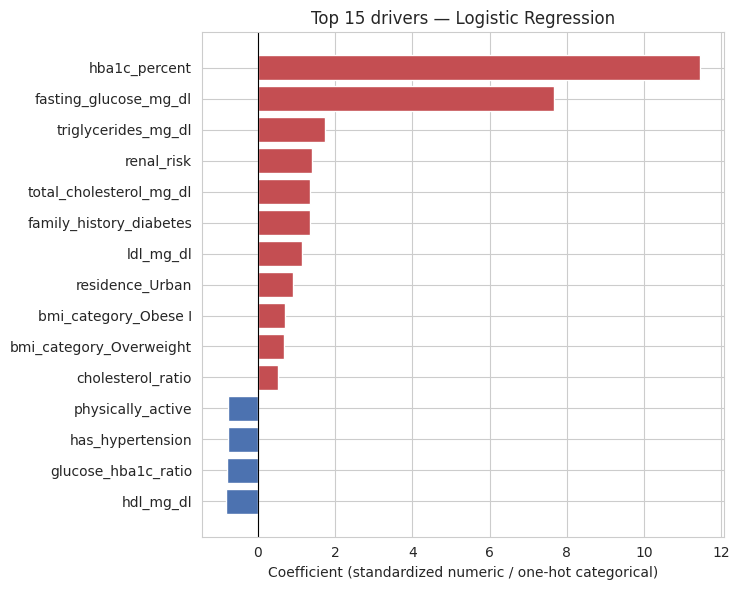

In [17]:
final_pipe = create_pipeline(models["Logistic Regression"])
final_pipe.fit(X, y)

fitted_preprocessor = final_pipe.named_steps["preprocessor"]
fitted_classifier = final_pipe.named_steps["classifier"]

ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(categorical_features))
feature_names = numeric_features + cat_names
coefs = fitted_classifier.coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
top15 = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index).head(15).sort_values("coef")

fig, ax = plt.subplots(figsize=(7.5, 6))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in top15["coef"]]
ax.barh(top15["feature"], top15["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardized numeric / one-hot categorical)")
ax.set_title("Top 15 drivers — Logistic Regression")
plt.tight_layout()
plt.show()


`hba1c_percent` and `fasting_glucose_mg_dl` dominate, as they should given
the label check above. `family_history_diabetes` and `renal_risk` now show
up with real, non-trivial coefficients — they're the two clearest
beneficiaries of the boolean-columns fix; both were completely invisible to
every model before it. `has_hypertension`'s coefficient is negative here,
which looks backwards clinically — most likely a suppressor effect from
`renal_risk` (which already bakes in `has_hypertension` as a multiplier),
not evidence that hypertension protects against diabetes. Worth stating
rather than glossing over.


### SHAP — explaining the model that's actually deployed

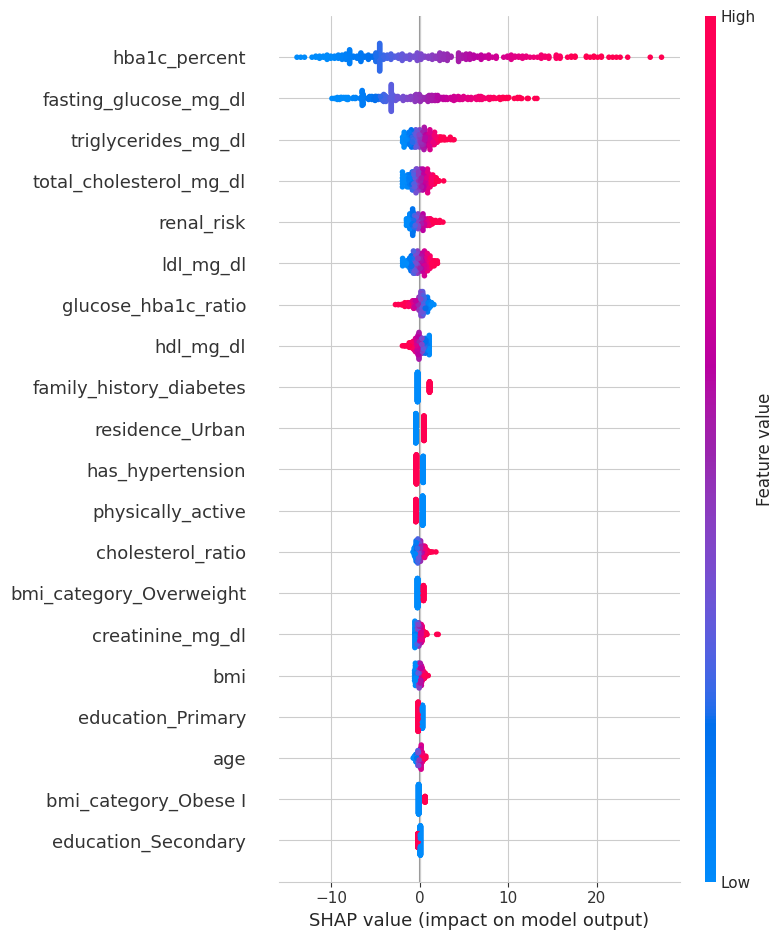

In [18]:
X_t = fitted_preprocessor.transform(X)
if hasattr(X_t, "toarray"):
    X_t = X_t.toarray()

# LinearExplainer computes exact SHAP values for a linear model, no
# sampling required. A generic shap.Explainer(predict_proba, background)
# was tried first and took ~7 seconds per row -- a real problem for a
# "click to predict" button in the app -- because it perturbs and
# re-predicts many times per call. LinearExplainer is the right tool now
# that the shipped model is linear, and it's near-instant.
explainer = shap.LinearExplainer(fitted_classifier, X_t[:500])

sample_idx = np.random.RandomState(42).choice(len(X_t), size=300, replace=False)
sv = explainer(X_t[sample_idx])
shap.summary_plot(sv.values, X_t[sample_idx], feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()


The original refit a brand-new `XGBClassifier` on `preprocessor.fit_transform(X)`
purely to have something for SHAP to explain — a second, separately-fit
model, close in hyperparameters but not literally the deployed object. This
explains `final_pipe`'s own fitted preprocessor and classifier directly, so
what SHAP shows here is faithful to what `app.py` actually serves.


## 6. Save the production model

In [19]:
joblib.dump({
    "pipeline": final_pipe,
    "model_name": "Logistic Regression",
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "boolean_features": bool_cols,
    "cv_results": results_df.to_dict("index"),
}, "../diabetes_production_model.pkl")
joblib.dump(explainer, "../shap_explainer.pkl")
print("Saved.")


Saved.


## Conclusion

- **The boolean-columns bug was the real story here.** `select_dtypes`
  silently dropped 8 clinical risk factors from every model in the original
  comparison; the Streamlit form's inputs for them were cosmetic. Fixed.
- `parity` was imputed from the wrong population (fabricating pregnancy
  history for men); `renal_risk` in the app had an operator-precedence bug
  that made it ignore hypertension entirely (see the app's own README
  section); Optuna's scoring key bug meant tuning never worked. All fixed.
- The headline ROC-AUC (~0.9998) reflects that `fasting_glucose_mg_dl` and
  `hba1c_percent` are the diagnostic criteria the label was built from, not
  genuine predictive difficulty — read it as "the pipeline works," not as
  "the model discovered something."
- Logistic Regression ships over five models that edge it out by a
  statistically meaningless margin, because its coefficients are directly
  auditable and SHAP is more trustworthy layered on a simple model.
